<a href="https://colab.research.google.com/github/claudia372440-lgtm/Cheflab/blob/main/Clasificad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Interfaz actualizada con botón de descarga.



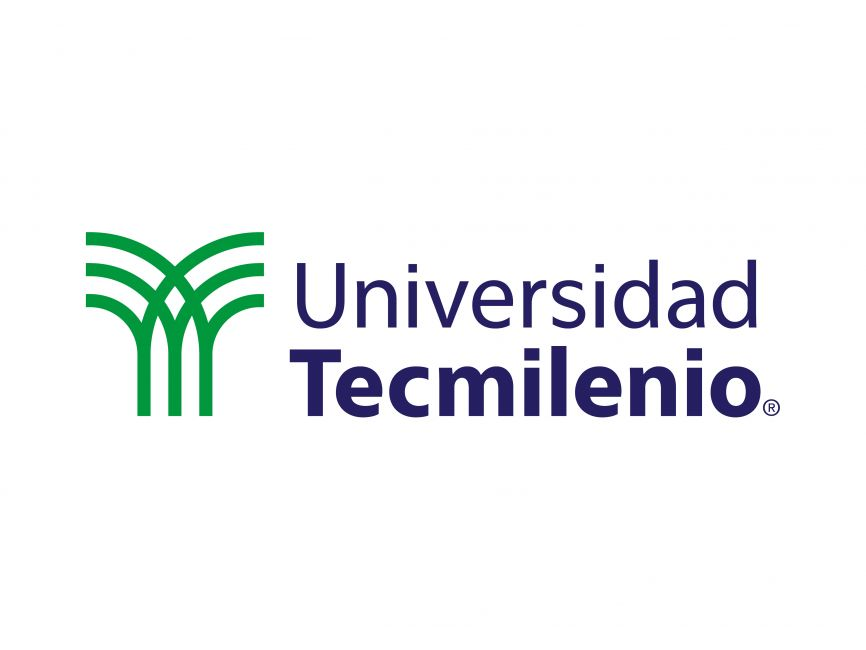

In [12]:
from IPython.display import HTML
import base64
from datetime import datetime

# 1. Definir variables
nombre_estudiante = "Claudia Rocio Velandia Velandia"
nombre_profesor = " Luis Ariel Vázquez Piña"
fecha = "5 de abril de 2026"

# 2. Codificar la imagen para el logo
image_path = '/content/universidad-tecmilenio9655.jpg'
try:
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    base64_encoded_image = base64.b64encode(image_bytes).decode('utf-8')
    image_data_uri = f"data:image/jpeg;base64,{base64_encoded_image}"
except FileNotFoundError:
    image_data_uri = ""

# 3. Crear el contenido HTML con el botón de descarga
html_content = f"""
<!DOCTYPE html>
<html lang='es'>
<head>
  <meta charset='UTF-8'>
  <title>Clasificador de Imágenes - Universidad Tecmilenio</title>
  <script src='https://cdn.jsdelivr.net/npm/@tensorflow/tfjs'></script>
  <style>
    body {{ font-family: Arial, sans-serif; text-align: center; background-color: #f5f5f5; margin: 0; padding: 20px; }}
    header {{ background-color: #009a3e; color: white; padding: 15px; }}
    h1 {{ text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); }}
    img.logo {{ width: 150px; margin-bottom: 10px; }}
    .container {{ background: white; border-radius: 10px; padding: 20px; box-shadow: 0 0 10px rgba(0,0,0,0.2); display: inline-block; }}
    #preview {{ width: 224px; height: 224px; object-fit: cover; border: 2px solid #009a3e; margin-top: 10px; }}
    #result {{ font-size: 18px; margin-top: 15px; color: #009a3e; font-weight: bold; }}
    .info-section {{ background-color: #e6ffe6; padding: 10px; margin-top: 20px; border-radius: 8px; color: #333; font-size: 14px; }}
    #downloadBtn {{ display: none; margin-top: 15px; padding: 10px 20px; background-color: #009a3e; color: white; border: none; border-radius: 5px; cursor: pointer; }}
    #downloadBtn:hover {{ background-color: #007a31; }}
  </style>
</head>
<body>
  <header>
    <img src='{image_data_uri}' alt='Logo Tecmilenio' class='logo'>
    <h1>Clasificador de Imágenes</h1>
    <h3>Proyecto académico - Fundamentos de la inteligencia artificial</h3>
  </header>

  <div class='info-section'>
    <p><b>Actividad 9</b></p>
    <p><b>Nombre del estudiante:</b> {nombre_estudiante}</p>
    <p><b>Nombre del profesor:</b> {nombre_profesor}</p>
    <p><b>Fecha:</b> {fecha}</p>
  </div>

  <div class='container'>
    <input type='file' id='imageInput' accept='image/*'>
    <br>
    <img id='preview' src='' alt='Vista previa'>
    <div id='result'>Cargando modelo...</div>
    <button id='downloadBtn'>Descargar Resultados (.txt)</button>
  </div>

  <script>
    let model, classNames, lastResult = '';

    async function loadModel() {{
      try {{
        model = await tf.loadLayersModel('model.json');
        const response = await fetch('labels.txt');
        classNames = await response.text();
        document.getElementById('result').innerText = 'Modelo cargado correctamente.';
      }} catch (e) {{
        document.getElementById('result').innerText = 'Error al cargar archivos (model.json/labels.txt)';
      }}
    }}

    async function predictImage(imageElement) {{
      const tensor = tf.browser.fromPixels(imageElement)
        .resizeNearestNeighbor([224, 224])
        .toFloat()
        .div(tf.scalar(127.5))
        .sub(tf.scalar(1))
        .expandDims();

      const prediction = await model.predict(tensor).data();
      const index = prediction.indexOf(Math.max(...prediction));
      const labelsArr = classNames.split('\\n');
      const confidence = (prediction[index] * 100).toFixed(2);

      const resultText = 'Clase: ' + labelsArr[index] + ' | Precisión: ' + confidence + '%';
      document.getElementById('result').innerText = resultText;

      // Guardar resultado para descarga y mostrar botón
      lastResult = '--- Resultado de Clasificación ---\\n' +
                 'Estudiante: {nombre_estudiante}\\n' +
                 'Fecha: ' + new Date().toLocaleString() + '\\n' +
                 resultText;
      document.getElementById('downloadBtn').style.display = 'inline-block';
    }}

    document.getElementById('imageInput').addEventListener('change', (event) => {{
      const file = event.target.files[0];
      const img = document.getElementById('preview');
      img.src = URL.createObjectURL(file);
      img.onload = () => predictImage(img);
    }});

    document.getElementById('downloadBtn').addEventListener('click', () => {{
      const blob = new Blob([lastResult], {{ type: 'text/plain' }});
      const url = window.URL.createObjectURL(blob);
      const a = document.createElement('a');
      a.href = url;
      a.download = 'resultado_clasificacion.txt';
      a.click();
      window.URL.revokeObjectURL(url);
    }});

    loadModel();
  </script>
</body>
</html>
"""

print("Interfaz actualizada con botón de descarga.")
HTML(html_content)

In [ ]:
!pip install tf-keras
import os
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf
import tf_keras
from google.colab import files

try:
    model_path = 'keras_model.h5'
    labels_path = 'labels.txt'

    # Cargar el modelo usando el motor de compatibilidad tf_keras
    print("Cargando modelo con tf_keras...")
    model = tf_keras.models.load_model(model_path, compile=False)

    # Cargar etiquetas
    with open(labels_path, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]

    print("\nPor favor, sube una imagen para clasificar:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Preprocesamiento de la imagen
        image = Image.open(filename).convert('RGB')
        size = (224, 224)
        image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
        img_array = (np.asarray(image).astype(np.float32) / 127.5) - 1
        data = np.expand_dims(img_array, axis=0)

        # Predicción
        prediction = model.predict(data)
        index = np.argmax(prediction)

        print(f'\n--- Clasificación Exitosa de {filename} ---')
        print(f'Clase: {class_names[index]}')
        print(f'Confianza: {prediction[0][index]*100:.2f}%')

except Exception as e:
    print(f'Error al procesar el modelo: {e}')

Cargando modelo con tf_keras...

Por favor, sube una imagen para clasificar:


Saving universidad-tecmilenio9655.jpg to universidad-tecmilenio9655 (1).jpg
1/1 [==============================] - 2s 2s/step

--- Clasificación Exitosa de universidad-tecmilenio9655 (1).jpg ---
Clase: 3 Camiseta Verde
Confianza: 41.42%


In [ ]:
import numpy as np
from PIL import Image, ImageOps
import tf_keras

try:
    image_path = '/content/P1140377.jpg'
    model_path = 'keras_model.h5'
    labels_path = 'labels.txt'

    # Cargar modelo y etiquetas si no están en memoria
    model = tf_keras.models.load_model(model_path, compile=False)
    with open(labels_path, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]

    # Preprocesar imagen
    image = Image.open(image_path).convert('RGB')
    size = (224, 224)
    image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    img_array = (np.asarray(image).astype(np.float32) / 127.5) - 1
    data = np.expand_dims(img_array, axis=0)

    # Predicción
    prediction = model.predict(data)
    index = np.argmax(prediction)

    print(f'\n--- Resultado de Clasificación ---')
    print(f'Imagen: {image_path}')
    print(f'Clase: {class_names[index]}')
    print(f'Confianza: {prediction[0][index]*100:.2f}%')

except Exception as e:
    print(f'Error al procesar la imagen seleccionada: {e}')

1/1 [==============================] - 1s 1s/step

--- Resultado de Clasificación ---
Imagen: /content/P1140377.jpg
Clase: 3 Camiseta Verde
Confianza: 95.42%


In [ ]:
!pip install tensorflowjs
import tensorflowjs as tfjs
import tensorflow as tf

try:
    # Cargamos el modelo ignorando errores de compilación
    model = tf.keras.models.load_model('keras_model.h5', compile=False, safe_mode=False)

    # Exportamos a formato web (TensorFlow.js)
    # Esto crea una carpeta con model.json y los archivos binarios de pesos
    tfjs.converters.save_keras_model(model, 'tfjs_model')

    # Movemos los archivos al directorio raíz para que el HTML los encuentre
    !cp tfjs_model/* /content/
    print('\n--- Conversión Exitosa ---')
    print('El modelo ahora es compatible con la interfaz HTML de arriba.')
    print('Por favor, vuelve a la celda del Clasificador de Imágenes (HTML) y ejecútala.')
except Exception as e:
    print(f'Error en la conversión: {e}')

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.1 requires pack

Error en la conversión: Exception encountered when calling Sequential.call().

Layer "functional_54" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1813>, <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1814>]

Arguments received by Sequential.call():
  • args=(('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1813>', '<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1814>'),)
  • kwargs={'mask': ('None', 'None')}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from google.colab import files
import os

print('Por favor, selecciona el archivo converted_keras.zip:')
uploaded = files.upload()

for fn in uploaded.keys():
  print('Archivo "{name}" subido con éxito.'.format(name=fn))

Por favor, selecciona el archivo converted_keras.zip:


Saving converted_keras.zip to converted_keras.zip
Archivo "converted_keras.zip" subido con éxito.


In [ ]:
!pip install tensorflow==2.15.0
print('Instalación completada. Por favor, ve al menú Entorno de ejecución > Reiniciar sesión para aplicar los cambios y luego ejecuta el clasificador.')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Instalación completada. Por favor, ve al menú Entorno de ejecución > Reiniciar sesión para aplicar los cambios y luego ejecuta el clasificador.


In [ ]:
import zipfile
import os

zip_path = '/content/converted_keras.zip'
extract_path = '/content/'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Archivos extraídos correctamente:')
    print(os.listdir(extract_path))
else:
    print(f'No se encontró el archivo {zip_path}. Por favor, asegúrate de haberlo subido.')

Archivos extraídos correctamente:
['.config', 'keras_model.h5', 'labels.txt', 'converted_keras.zip', 'sample_data']


In [ ]:
!ls /content/

converted_keras.zip  keras_model.h5  labels.txt  sample_data
